In [ ]:
# 06 — Contraste de Hipótesis
'''
En este notebook evaluamos las cuatro hipótesis definidas al inicio del proyecto.  
Utilizamos los datasets ya limpiados y las visualizaciones generadas en notebooks anteriores, ampliando el análisis con nuevas comparaciones, métricas e interpretaciones.

Las hipótesis son:

**H1 — La contaminación atmosférica aumenta el impacto en la salud respiratoria**  
Se espera que los años con mayores niveles de contaminación presenten también un aumento en hospitalizaciones y mortalidad respiratoria.

**H2 — Las estaciones urbanas y de tráfico presentan mayores niveles de contaminación**  
Las estaciones clasificadas como tráfico y urbano deberían registrar concentraciones más altas que las estaciones rurales o de fondo.

**H3 — Las zonas costeras presentan menor contaminación que las zonas de interior**  
La dispersión atmosférica suele ser mejor en áreas cercanas al mar, por lo que se anticipan niveles más bajos en estaciones costeras.

**H4 — El ozono (O₃) aumenta en verano debido a procesos fotoquímicos**  
El ozono troposférico depende de la radiación solar, por lo que se espera observar un patrón estacional claro con valores más altos en verano.
'''

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

'''
configuración estética global para los gráficos:
-sns.set(style="whitegrid"): aplica un estilo limpio con fondo cuadriculado, adecuado para análisis exploratorios.
-plt.rcParams["figure.figsize"]: define el tamaño por defecto de todas las figuras (12x6 pulgadas), garantizando visualizaciones legibles y consistentes.
'''

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

# cargo los dataset y el merged

df_hospi = pd.read_csv("../data/context_clean/hospitalizations_clean.csv")
df_mortality = pd.read_csv("../data/context_clean/mortality_clean.csv")
df_population = pd.read_csv("../data/context_clean/population_clean.csv")

df_pollutants_stations = pd.read_parquet("../data/integrated/df_pollutants_stations.parquet")


In [4]:
df_hospi.head()

,region,year,hospitalizations
0,ES,2011,518276
1,ES,2012,524962
2,ES,2013,506929
3,ES,2014,531124
4,ES,2015,426914


In [5]:
df_mortality.head()

,region,year,deaths
0,ES,2011,42125
1,ES,2012,47237
2,ES,2013,42444
3,ES,2014,43699
4,ES,2015,51711


In [6]:
df_population.head()

,region,year,population
0,ES,2011,46742697
1,ES,2012,46773055
2,ES,2013,46604197
3,ES,2014,46460733
4,ES,2015,46422303


In [7]:
df_pollutants_stations.head()

,date,Samplingpoint,Value,NatCode,Year,Air Pollutant,Air Quality Station EoI Code,Air Quality Station Name,Sampling Point Id,Longitude,Latitude,Municipality,Air Quality Station Area,Air Quality Station Type,Altitude,Main Emission Sources,pollutant
0,2011-01-01,ES/SP_09059006_9_49,10.956522,09059006,2025,SO2,ES1443A,BURGOS 4,SP_09059006_1_38,-3.63611,42.33611,BURGOS,urban,background,929.0,"Land use, land use change and forestry",PM25
1,2011-01-01,ES/SP_28007004_9_49,19.739130,28007004,2025,NOX as NO2,ES1890A,ALCORCÓN,SP_28007004_12_8,-3.83370,40.34190,ALCORCÓN,urban,background,693.0,NaN,PM25
2,2011-01-01,ES/SP_28148004_9_49,14.409091,28148004,2025,PM10,ES1752A,TORREJON DE ARDOZ,SP_28148004_10_49,-3.47760,40.44950,TORREJÓN DE ARDOZ,suburban,background,581.0,NaN,PM25
3,2011-01-02,ES/SP_09059006_9_49,4.500000,09059006,2025,SO2,ES1443A,BURGOS 4,SP_09059006_1_38,-3.63611,42.33611,BURGOS,urban,background,929.0,"Land use, land use change and forestry",PM25
4,2011-01-02,ES/SP_28007004_9_49,9.291667,28007004,2025,NOX as NO2,ES1890A,ALCORCÓN,SP_28007004_12_8,-3.83370,40.34190,ALCORCÓN,urban,background,693.0,NaN,PM25


## H1 — La contaminación atmosférica aumenta el impacto en la salud respiratoria

Para evaluar esta hipótesis, analizamos primero la evolución de las hospitalizaciones respiratorias, la mortalidad respiratoria, la población y los indicadores derivados (tasas por 100.000 habitantes y porcentaje de letalidad hospitalaria).

Estos indicadores permiten entender la carga de enfermedad respiratoria independientemente del tamaño poblacional.

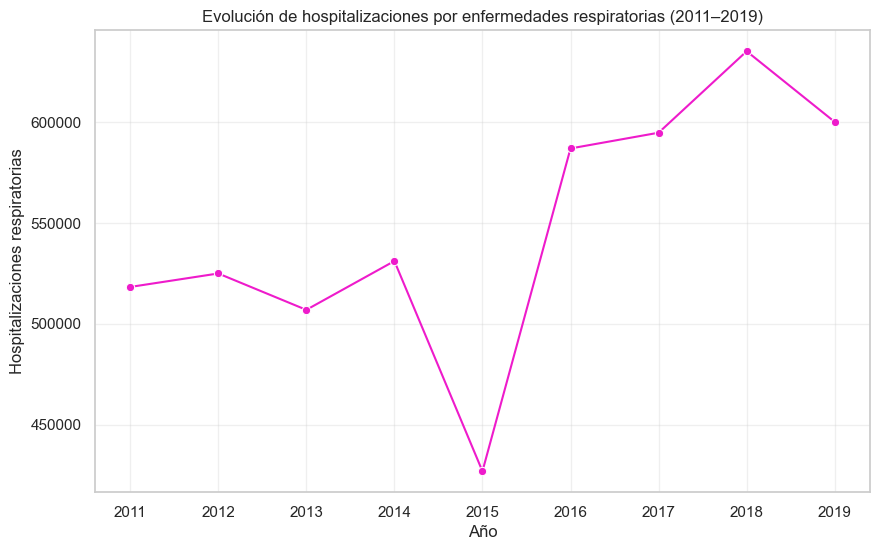

In [8]:
# hospitalizaciones respiratorias (2011-2019)

plt.figure(figsize=(10,6))
sns.lineplot(data=df_hospi,x='year',y='hospitalizations',marker='o',color="#ee1bcb")
plt.title("Evolución de hospitalizaciones por enfermedades respiratorias (2011–2019)")
plt.xlabel("Año")
plt.ylabel("Hospitalizaciones respiratorias")
plt.grid(alpha=0.3)
plt.show()

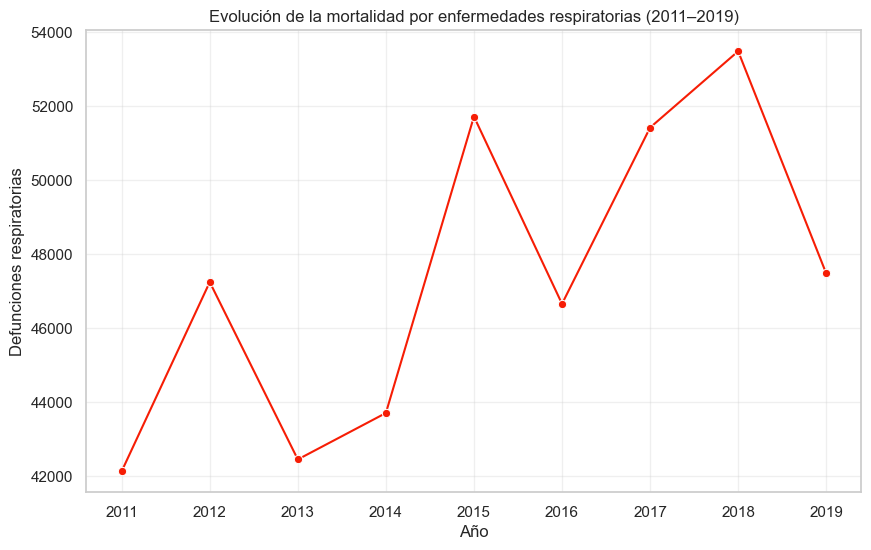

In [9]:
# mortalidad respiratoria (2011-2019)

plt.figure(figsize=(10,6))
sns.lineplot(data=df_mortality,x='year',y='deaths',marker='o',color="#f61d05")
plt.title("Evolución de la mortalidad por enfermedades respiratorias (2011–2019)")
plt.xlabel("Año")
plt.ylabel("Defunciones respiratorias")
plt.grid(alpha=0.3)
plt.show()

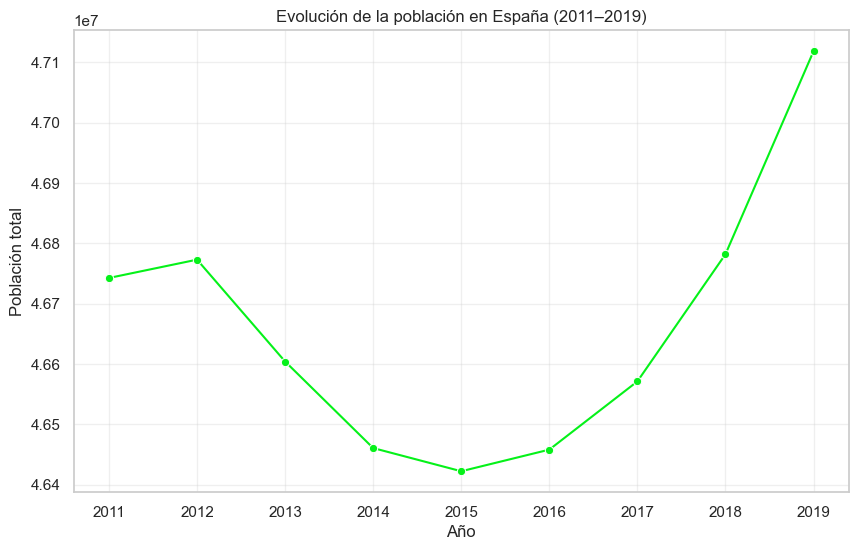

In [10]:
# población (2011-2019)

plt.figure(figsize=(10,6))
sns.lineplot(data=df_population,x='year',y='population',marker='o',color="#05f119")
plt.title("Evolución de la población en España (2011–2019)")
plt.xlabel("Año")
plt.ylabel("Población total")
plt.grid(alpha=0.3)
plt.show()

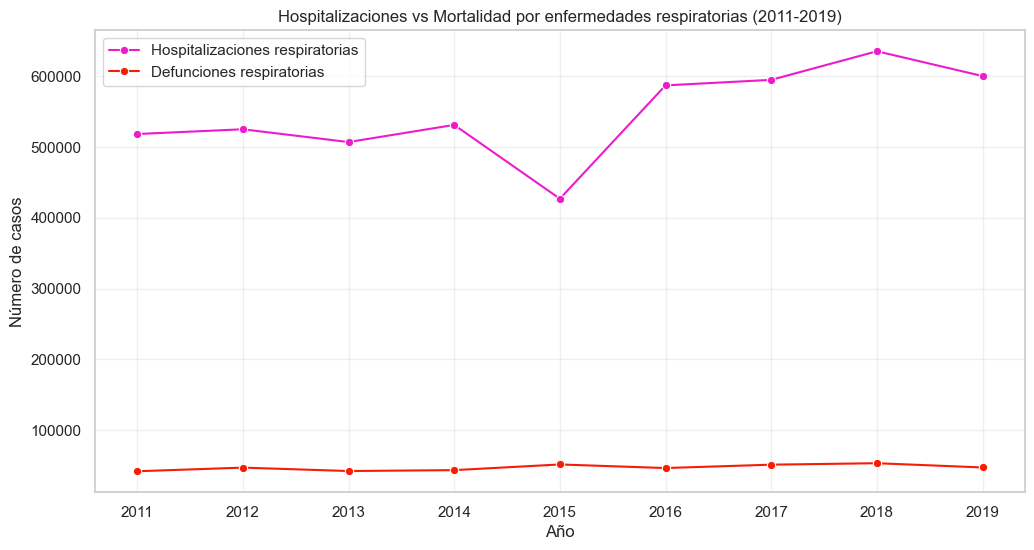

In [11]:
# comparativa hospitalizaciones respiratorias vs mortalidad respiratoria

plt.figure(figsize=(12,6))

sns.lineplot(data=df_hospi,x='year',y='hospitalizations',marker='o',label='Hospitalizaciones respiratorias',color="#ee1bcb")

sns.lineplot(data=df_mortality,x='year',y='deaths',marker='o',label='Defunciones respiratorias',color="#f61d05")

plt.title("Hospitalizaciones vs Mortalidad por enfermedades respiratorias (2011-2019)")
plt.xlabel("Año")
plt.ylabel("Número de casos")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

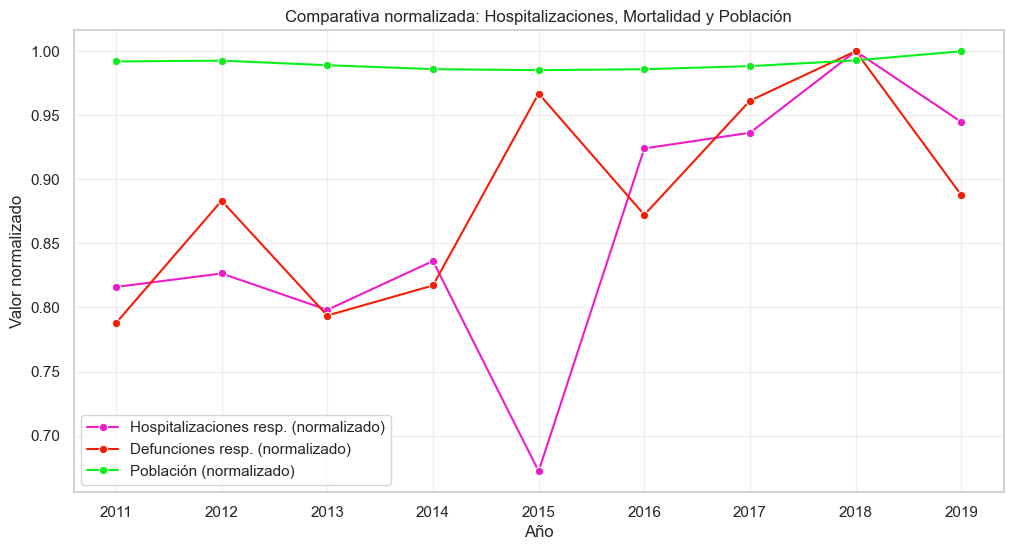

In [12]:
# comparativa de hospitalizaciones, mortalidad y población

# fusionamos los tres df
df_plot = (df_hospi.merge(df_mortality, on=['region','year']).merge(df_population, on=['region','year']))

# normalizamos para comparar tendencias
df_norm = df_plot.copy()
df_norm['hospitalizations_norm'] = df_norm['hospitalizations'] / df_norm['hospitalizations'].max()
df_norm['deaths_norm'] = df_norm['deaths'] / df_norm['deaths'].max()
df_norm['population_norm'] = df_norm['population'] / df_norm['population'].max()

plt.figure(figsize=(12,6))

sns.lineplot(data=df_norm,x='year',y='hospitalizations_norm',marker='o',label='Hospitalizaciones resp. (normalizado)',color="#ee1bcb")

sns.lineplot(data=df_norm,x='year',y='deaths_norm',marker='o',label='Defunciones resp. (normalizado)',color="#f61d05")

sns.lineplot(data=df_norm,x='year',y='population_norm',marker='o',label='Población (normalizado)',color="#05f119")

plt.title("Comparativa normalizada: Hospitalizaciones, Mortalidad y Población")
plt.xlabel("Año")
plt.ylabel("Valor normalizado")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [13]:
# voy a calcular las tasas por 100.000 habitantes para hospitalizaciones respiratorias y mortalidad respiratoria

# unimos hospitalizaciones, mortalidad y población por año
df_health = (df_hospi.merge(df_mortality, on=['region','year']).merge(df_population, on=['region','year']))
df_health

,region,year,hospitalizations,deaths,population
0,ES,2011,518276,42125,46742697
1,ES,2012,524962,47237,46773055
2,ES,2013,506929,42444,46604197
3,ES,2014,531124,43699,46460733
4,ES,2015,426914,51711,46422303
5,ES,2016,586945,46649,46458139
6,ES,2017,594741,51413,46571232
7,ES,2018,635132,53476,46782011
8,ES,2019,600088,47470,47118501


In [14]:
# calculo de tasas por 100.000 habitantes
df_health['hospitalizations_rate'] = (df_health['hospitalizations'] / df_health['population']) * 100000
df_health['mortality_rate'] = (df_health['deaths'] / df_health['population']) * 100000

df_health

,region,year,hospitalizations,deaths,population,hospitalizations_rate,mortality_rate
0,ES,2011,518276,42125,46742697,1108.784972,90.121030
1,ES,2012,524962,47237,46773055,1122.359872,100.991907
2,ES,2013,506929,42444,46604197,1087.732506,91.073343
3,ES,2014,531124,43699,46460733,1143.167500,94.055770
4,ES,2015,426914,51711,46422303,919.631238,111.392578
5,ES,2016,586945,46649,46458139,1263.384657,100.410824
6,ES,2017,594741,51413,46571232,1277.056617,110.396478
7,ES,2018,635132,53476,46782011,1357.641509,114.308895
8,ES,2019,600088,47470,47118501,1273.571925,100.745989


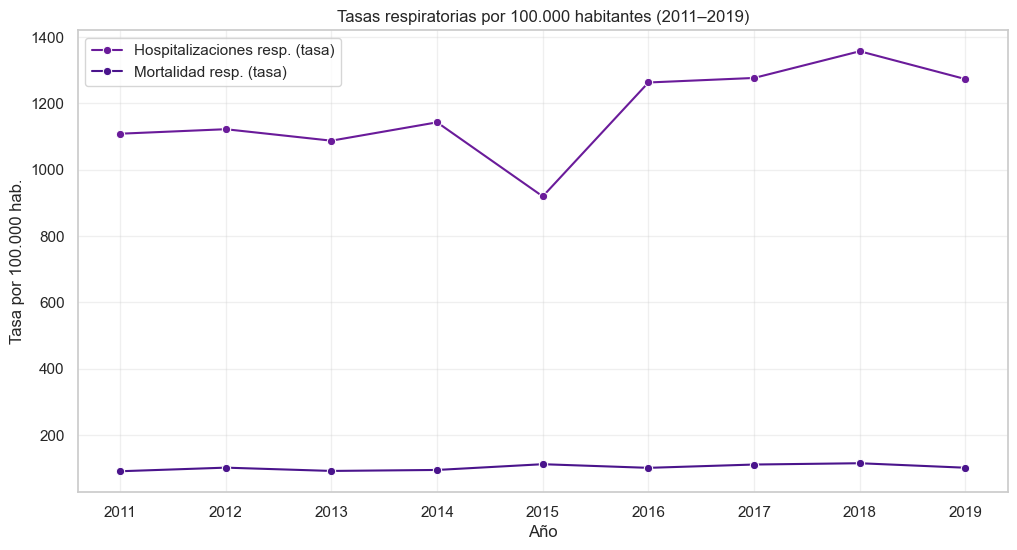

In [15]:
# comparativa de tasas (hospitalizaciones vs mortalidad)
plt.figure(figsize=(12,6))

sns.lineplot(data=df_health, x='year', y='hospitalizations_rate',
             marker='o', label='Hospitalizaciones resp. (tasa)', color='#6a1b9a')

sns.lineplot(data=df_health, x='year', y='mortality_rate',
             marker='o', label='Mortalidad resp. (tasa)', color='#4a148c')

plt.title("Tasas respiratorias por 100.000 habitantes (2011–2019)")
plt.xlabel("Año")
plt.ylabel("Tasa por 100.000 hab.")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

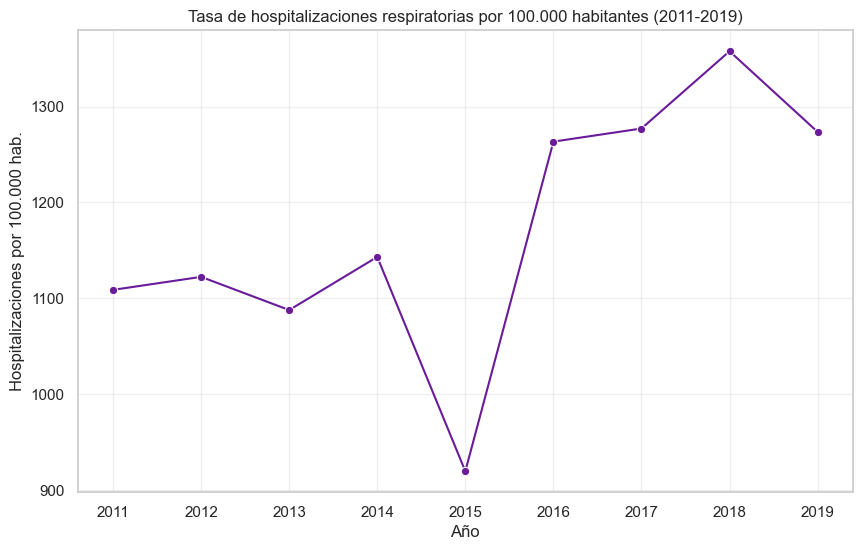

In [16]:
# gráfica de tasa de hospitalizaciones respiratorias
plt.figure(figsize=(10,6))
sns.lineplot(data=df_health,x='year',y='hospitalizations_rate',marker='o',color='#6a1b9a')
plt.title("Tasa de hospitalizaciones respiratorias por 100.000 habitantes (2011-2019)")
plt.xlabel("Año")
plt.ylabel("Hospitalizaciones por 100.000 hab.")
plt.grid(alpha=0.3)
plt.show()

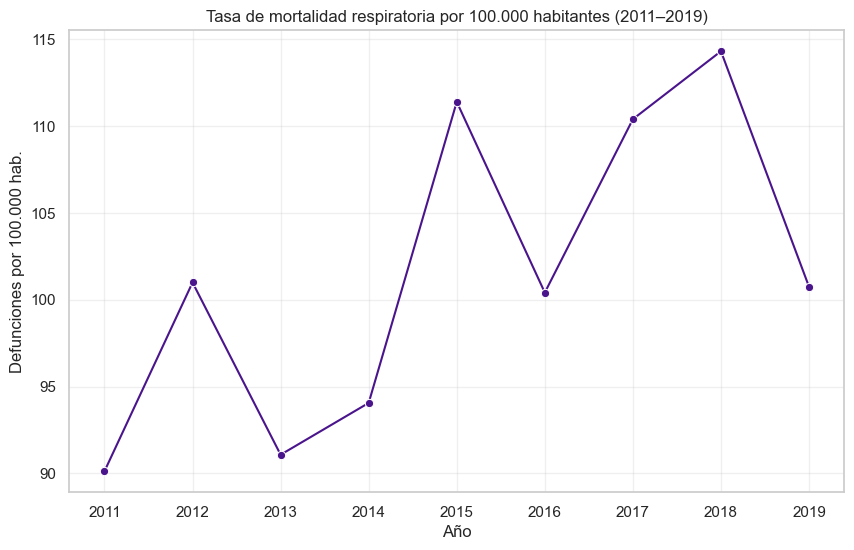

In [17]:
# gráfica de tasa de mortalidad respiratoria
plt.figure(figsize=(10,6))
sns.lineplot(data=df_health,x='year',y='mortality_rate',marker='o',color='#4a148c')
plt.title("Tasa de mortalidad respiratoria por 100.000 habitantes (2011–2019)")
plt.xlabel("Año")
plt.ylabel("Defunciones por 100.000 hab.")
plt.grid(alpha=0.3)
plt.show()

In [18]:
# porcentaje de personas hospitalizadas por enfermedades respiratorias que terminan falleciendo por causas respiratorias
df_health['fatality_pct'] = (df_health['deaths'] / df_health['hospitalizations']) * 100
df_health['fatality_pct'] = df_health['fatality_pct'].round(2)

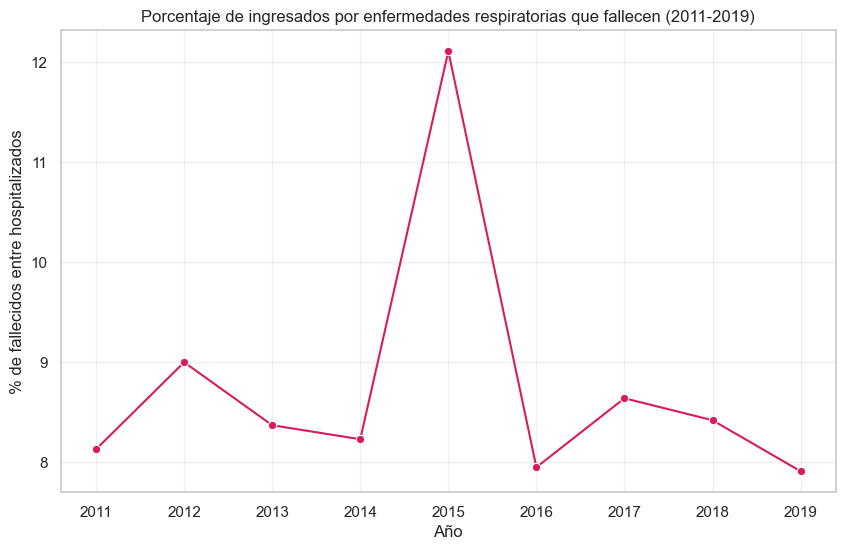

In [19]:
# la letalidad hospitalaria respiratoria suele oscilar entre 7% y 10%
# gráfica del porcentaje de letalidad respiratoria

plt.figure(figsize=(10,6))
sns.lineplot(data=df_health,x='year',y='fatality_pct',marker='o',color='#d81b60')
plt.title("Porcentaje de ingresados por enfermedades respiratorias que fallecen (2011-2019)")
plt.xlabel("Año")
plt.ylabel("% de fallecidos entre hospitalizados")
plt.grid(alpha=0.3)
plt.show()

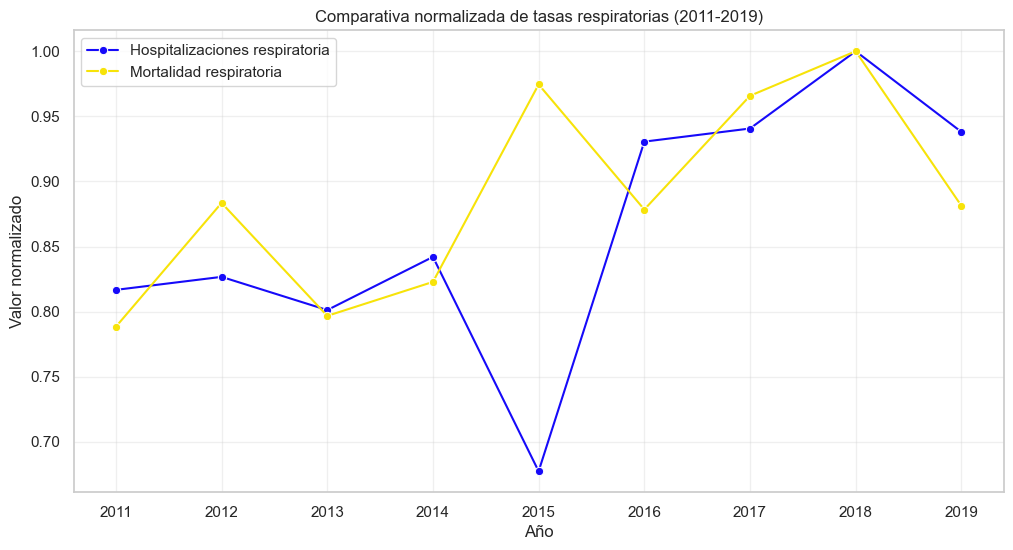

In [20]:
# comparativa normalizada de tasas (tendencias relativas), muy útil para ver si ambas curvas suben/bajan a la vez

df_norm_rates = df_health.copy()
df_norm_rates['hospitalizations_rate_norm'] = df_norm_rates['hospitalizations_rate'] / df_norm_rates['hospitalizations_rate'].max()
df_norm_rates['mortality_rate_norm'] = df_norm_rates['mortality_rate'] / df_norm_rates['mortality_rate'].max()

plt.figure(figsize=(12,6))

sns.lineplot(data=df_norm_rates,x='year',y='hospitalizations_rate_norm',marker='o',label='Hospitalizaciones respiratoria',color="#160af9")

sns.lineplot(data=df_norm_rates,x='year',y='mortality_rate_norm',marker='o',label='Mortalidad respiratoria',color="#f7e309")

plt.title("Comparativa normalizada de tasas respiratorias (2011-2019)")
plt.xlabel("Año")
plt.ylabel("Valor normalizado")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [ ]:
# antes hice indicadores de salud respiratoria (hospitalizaciones, mortalidad, tasas, letalidad…)

# ahora haré relación salud con  contaminación(merge, comparativas, correlaciones, conclusión)

## H1 Relación entre contaminación atmosférica y salud respiratoria

En esta sección analizamos si existe relación entre los indicadores de salud respiratoria
(hospitalizaciones, mortalidad, tasas y letalidad) y los niveles de contaminación atmosférica.

El objetivo es evaluar si los años con mayor concentración de contaminantes presentan
también un mayor impacto en la salud respiratoria, tal como plantea la hipótesis H1.

In [21]:
# agregación anual de contaminantes, agrupamos por año para obtener la concentración media anual de cada contaminante


# limpiar valores negativos
df_pollutants_stations["Value"] = df_pollutants_stations["Value"].mask(
    df_pollutants_stations["Value"] < 0,
    np.nan
)

# extraer el año REAL desde la columna date
df_pollutants_stations["date"] = pd.to_datetime(df_pollutants_stations["date"])
df_pollutants_stations["year"] = df_pollutants_stations["date"].dt.year

# agregación anual de contaminantes
pollutants_yearly = (df_pollutants_stations.pivot_table(index="year",columns="pollutant",values="Value",aggfunc="mean").reset_index())

pollutants_yearly

pollutant,year,C6H6,CO,NO2,O3,PM10,PM25,SO2
0,2011,NaN,NaN,NaN,57.605000,NaN,11.795948,NaN
1,2012,NaN,NaN,NaN,58.131193,NaN,10.691616,NaN
2,2013,0.687336,0.315632,19.617679,61.795513,36.046411,8.414929,11.961480
3,2014,0.675224,0.282245,17.821290,59.079797,19.026906,8.440634,4.602034
4,2015,0.745848,0.304125,19.510600,58.367238,20.601320,9.642178,4.690040
5,2016,0.639614,0.308748,18.082504,57.914092,18.724881,8.522382,4.259838
6,2017,0.605762,0.312260,19.153453,56.394518,20.996774,9.665476,4.409768
7,2018,0.558097,0.302889,16.768758,58.206911,18.811840,9.112622,4.032753
8,2019,0.540079,0.318126,16.168204,58.722936,19.164135,9.131447,4.001003


In [22]:
# unimos salud + contaminación
df_health_pollut = df_health.merge(pollutants_yearly,on="year",how="left")

df_health_pollut

,region,year,hospitalizations,deaths,population,hospitalizations_rate,mortality_rate,fatality_pct,C6H6,CO,NO2,O3,PM10,PM25,SO2
0,ES,2011,518276,42125,46742697,1108.784972,90.121030,8.13,NaN,NaN,NaN,57.605000,NaN,11.795948,NaN
1,ES,2012,524962,47237,46773055,1122.359872,100.991907,9.00,NaN,NaN,NaN,58.131193,NaN,10.691616,NaN
2,ES,2013,506929,42444,46604197,1087.732506,91.073343,8.37,0.687336,0.315632,19.617679,61.795513,36.046411,8.414929,11.961480
3,ES,2014,531124,43699,46460733,1143.167500,94.055770,8.23,0.675224,0.282245,17.821290,59.079797,19.026906,8.440634,4.602034
4,ES,2015,426914,51711,46422303,919.631238,111.392578,12.11,0.745848,0.304125,19.510600,58.367238,20.601320,9.642178,4.690040
5,ES,2016,586945,46649,46458139,1263.384657,100.410824,7.95,0.639614,0.308748,18.082504,57.914092,18.724881,8.522382,4.259838
6,ES,2017,594741,51413,46571232,1277.056617,110.396478,8.64,0.605762,0.312260,19.153453,56.394518,20.996774,9.665476,4.409768
7,ES,2018,635132,53476,46782011,1357.641509,114.308895,8.42,0.558097,0.302889,16.768758,58.206911,18.811840,9.112622,4.032753
8,ES,2019,600088,47470,47118501,1273.571925,100.745989,7.91,0.540079,0.318126,16.168204,58.722936,19.164135,9.131447,4.001003


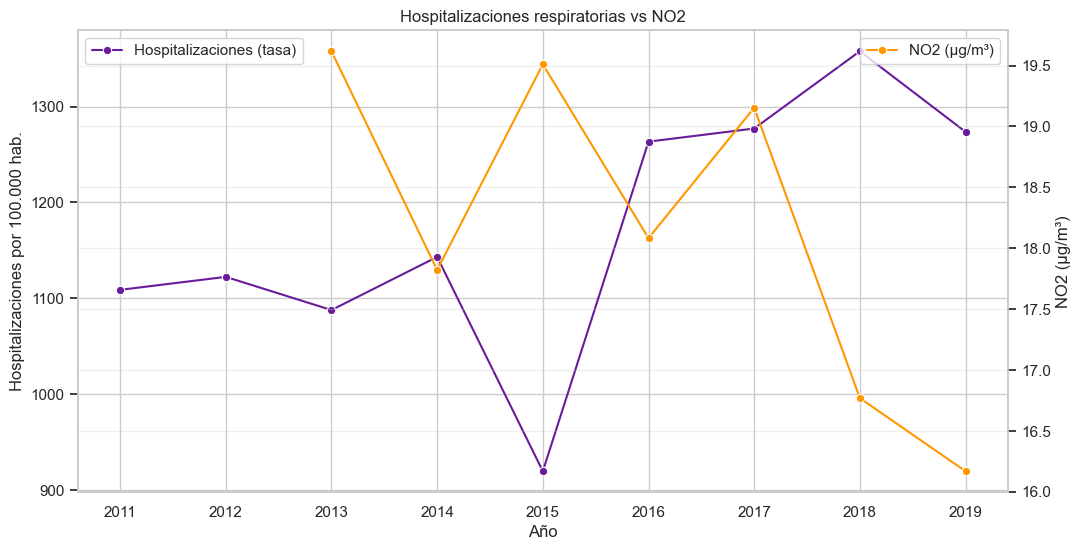

In [37]:
# gráficas comparadas: salud vs contaminantes

#  hospitalizaciones vs NO2
fig, ax1 = plt.subplots(figsize=(12,6))

sns.lineplot(data=df_health_pollut, x="year", y="hospitalizations_rate",marker="o", color="#6a1b9a", label="Hospitalizaciones (tasa)", ax=ax1)

ax2 = ax1.twinx()
sns.lineplot(data=df_health_pollut, x="year", y="NO2",marker="o", color="#ff9800", label="NO2 (µg/m³)", ax=ax2)

ax1.set_title("Hospitalizaciones respiratorias vs NO2")
ax1.set_xlabel("Año")
ax1.set_ylabel("Hospitalizaciones por 100.000 hab.")
ax2.set_ylabel("NO2 (µg/m³)")

plt.grid(alpha=0.3)
plt.show()

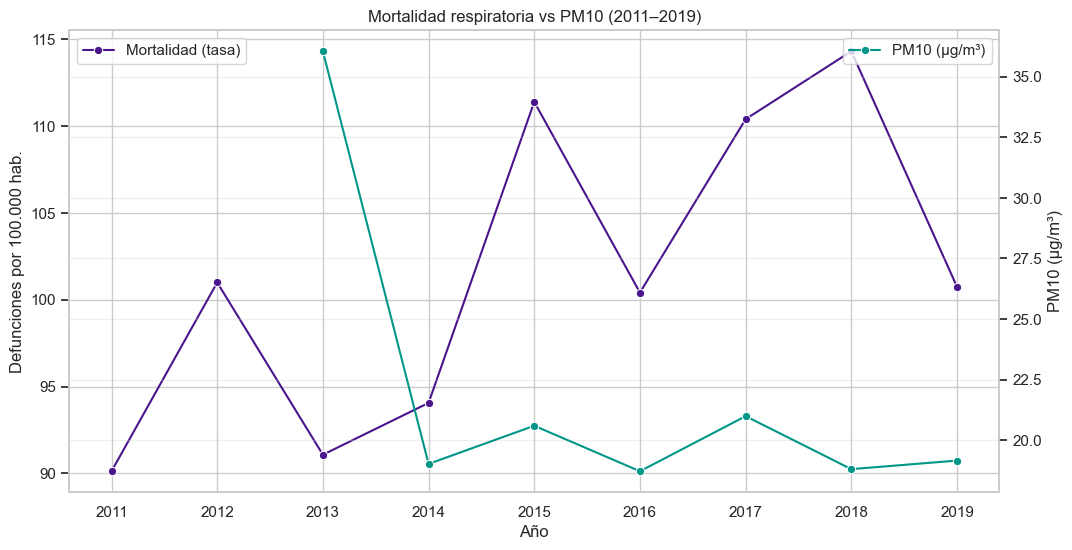

In [24]:
# mortalidad vs PM10
fig, ax1 = plt.subplots(figsize=(12,6))

sns.lineplot(data=df_health_pollut, x="year", y="mortality_rate",marker="o", color="#4a148c", label="Mortalidad (tasa)", ax=ax1)

ax2 = ax1.twinx()
sns.lineplot(data=df_health_pollut, x="year", y="PM10",marker="o", color="#009688", label="PM10 (µg/m³)", ax=ax2)

ax1.set_title("Mortalidad respiratoria vs PM10 (2011–2019)")
ax1.set_xlabel("Año")
ax1.set_ylabel("Defunciones por 100.000 hab.")
ax2.set_ylabel("PM10 (µg/m³)")

plt.grid(alpha=0.3)
plt.show()

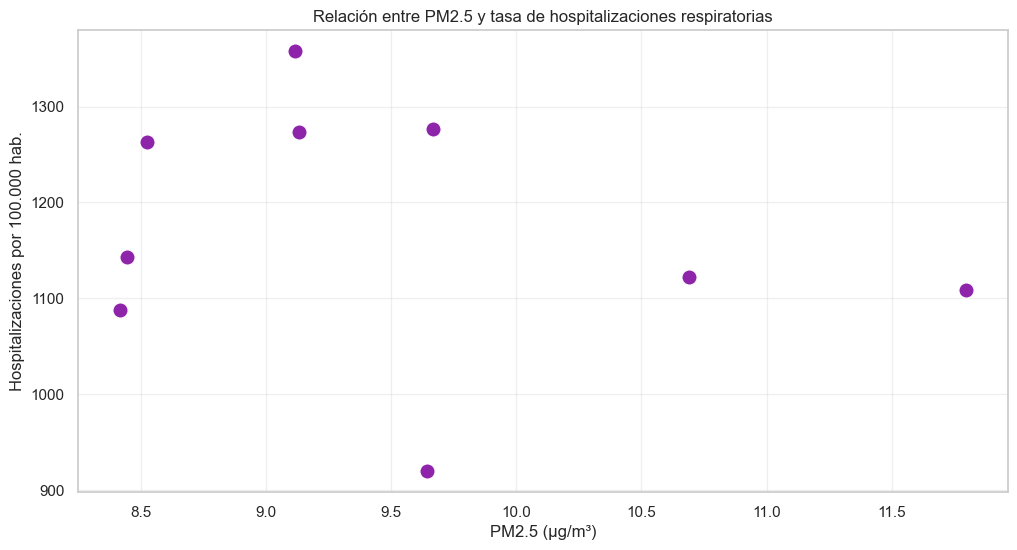

In [25]:
# tasas respiratorias vs PM2.5

plt.figure(figsize=(12,6))
sns.scatterplot(data=df_health_pollut, x="PM25", y="hospitalizations_rate",s=120, color="#8e24aa")
plt.title("Relación entre PM2.5 y tasa de hospitalizaciones respiratorias")
plt.xlabel("PM2.5 (µg/m³)")
plt.ylabel("Hospitalizaciones por 100.000 hab.")
plt.grid(alpha=0.3)
plt.show()

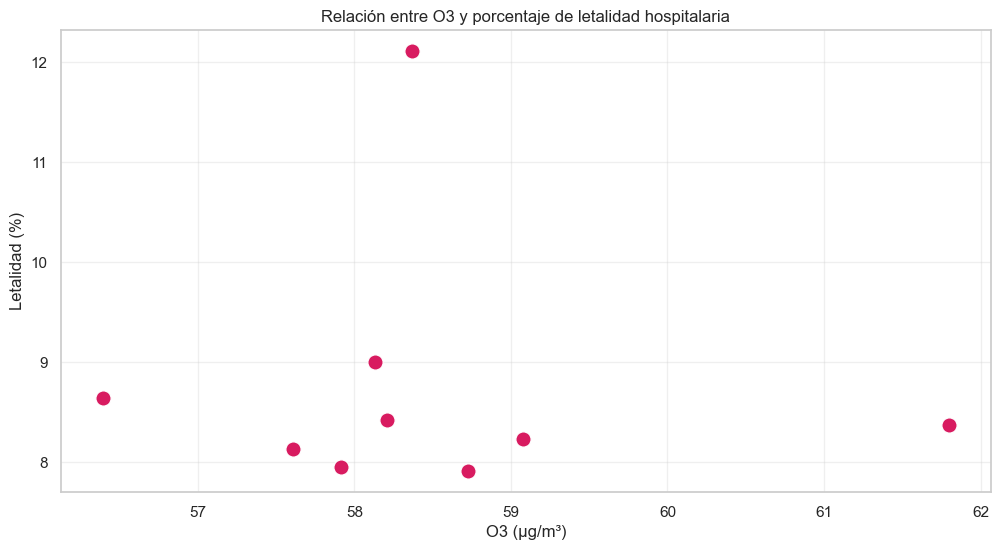

In [26]:
#  letalidad hospitalaria vs O3
plt.figure(figsize=(12,6))
sns.scatterplot(data=df_health_pollut, x="O3", y="fatality_pct",s=120, color="#d81b60")
plt.title("Relación entre O3 y porcentaje de letalidad hospitalaria")
plt.xlabel("O3 (µg/m³)")
plt.ylabel("Letalidad (%)")
plt.grid(alpha=0.3)
plt.show()

In [27]:
# correlaciones salud <-> contaminación

corr = df_health_pollut[["hospitalizations_rate", "mortality_rate", "fatality_pct","NO2", "PM10", "PM25", "O3"]].corr()

corr

,hospitalizations_rate,mortality_rate,fatality_pct,NO2,PM10,PM25,O3
hospitalizations_rate,1.000000,0.260341,-0.722384,-0.674909,-0.357795,-0.247635,-0.316119
mortality_rate,0.260341,1.000000,0.475744,-0.091954,-0.532233,-0.102245,-0.495514
fatality_pct,-0.722384,0.475744,1.000000,0.520201,-0.040979,0.128195,-0.060834
NO2,-0.674909,-0.091954,0.520201,1.000000,0.566566,0.109868,0.177164
PM10,-0.357795,-0.532233,-0.040979,0.566566,1.000000,-0.355650,0.797175
PM25,-0.247635,-0.102245,0.128195,0.109868,-0.355650,1.000000,-0.487156
O3,-0.316119,-0.495514,-0.060834,0.177164,0.797175,-0.487156,1.000000


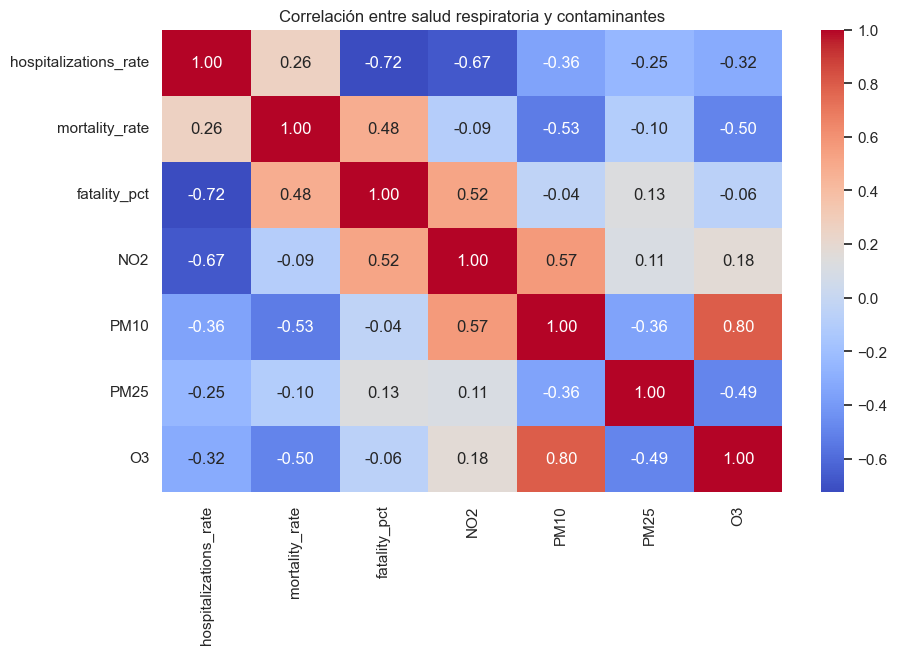

In [28]:
plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlación entre salud respiratoria y contaminantes")
plt.show()

# rojo = correlación positiva alta (cercana a +1)
# azul = correlación negativa alta (cercana a –1)
# blanco = correlación débil o nula (cercana a 0)

In [ ]:
# 2.5 Interpretación de resultados (texto listo para tu notebook)

In [ ]:
# 2.6 Conclusión de H1

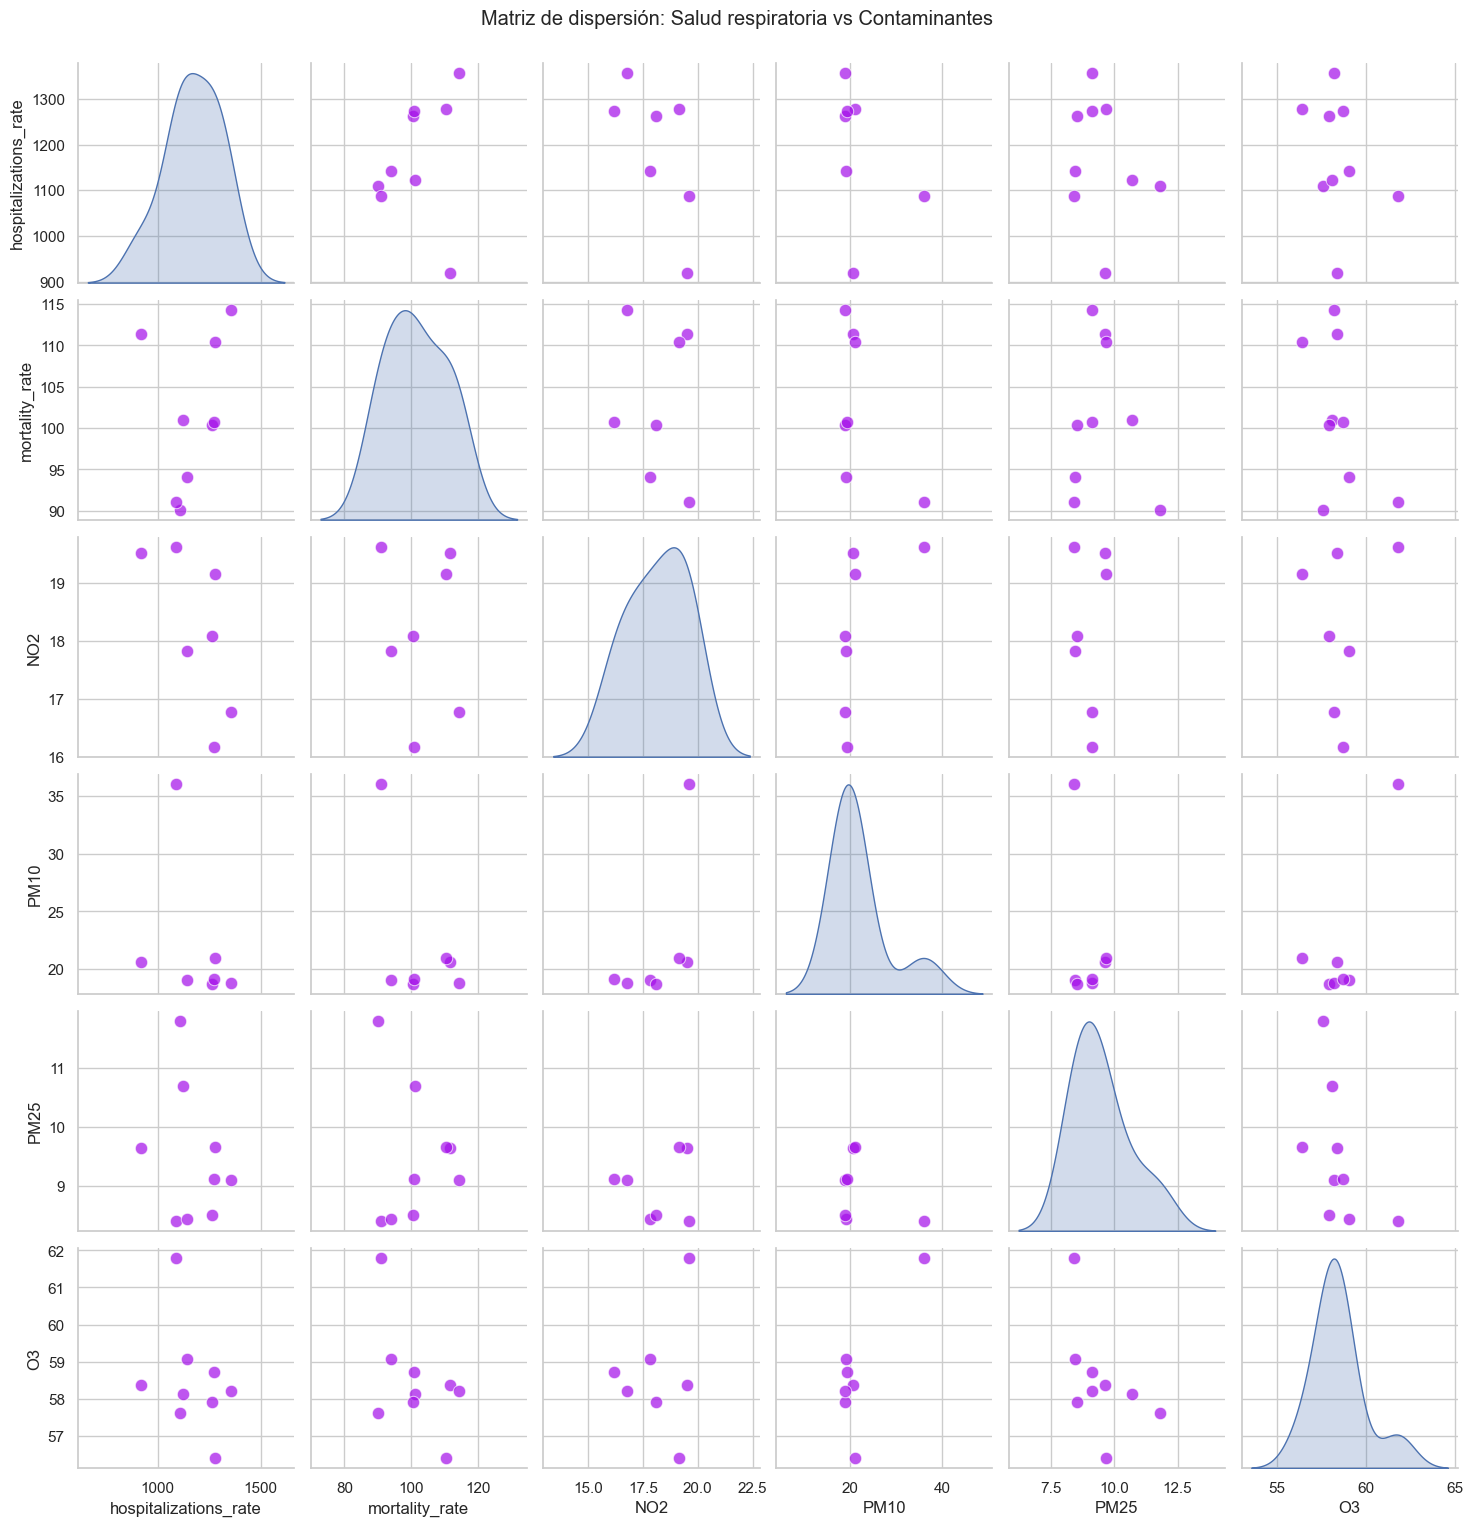

In [32]:
# gráfico multivariante: scatter matrix (pairplot)


vars_health_pollut = ["hospitalizations_rate", "mortality_rate", "NO2", "PM10", "PM25", "O3"]

sns.pairplot(df_health_pollut[vars_health_pollut], diag_kind="kde",
             plot_kws={"s": 80, "alpha": 0.7, "color": "#a30de9"})
plt.suptitle("Matriz de dispersión: Salud respiratoria vs Contaminantes", y=1.02)
plt.show()

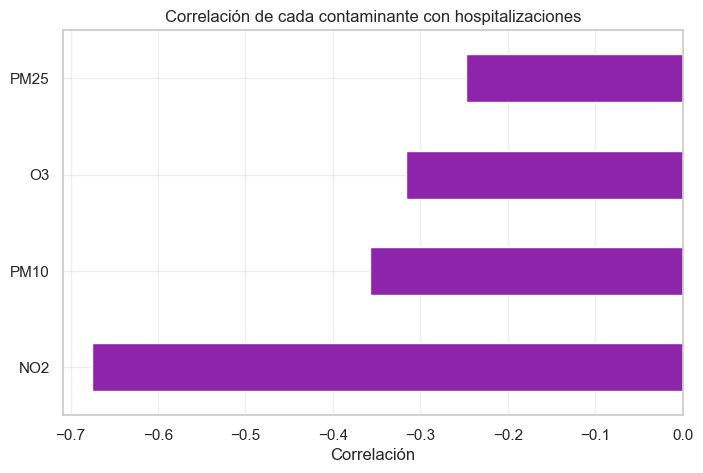

In [33]:
# correlaciones dirigidas: barras para hospitalizaciones

corr_hospi = df_health_pollut[["hospitalizations_rate", "NO2", "PM10", "PM25", "O3"]].corr()["hospitalizations_rate"]
corr_hospi = corr_hospi.drop("hospitalizations_rate").sort_values()

plt.figure(figsize=(8,5))
corr_hospi.plot(kind="barh", color="#8e24aa")
plt.title("Correlación de cada contaminante con hospitalizaciones")
plt.xlabel("Correlación")
plt.grid(alpha=0.3)
plt.show()


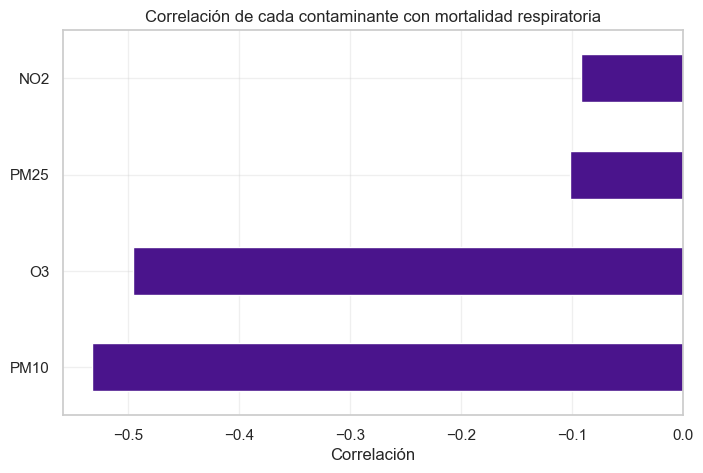

In [34]:
# correlaciones dirigidas: barras para mortalidad


corr_mort = df_health_pollut[["mortality_rate", "NO2", "PM10", "PM25", "O3"]].corr()["mortality_rate"]
corr_mort = corr_mort.drop("mortality_rate").sort_values()

plt.figure(figsize=(8,5))
corr_mort.plot(kind="barh", color="#4a148c")
plt.title("Correlación de cada contaminante con mortalidad respiratoria")
plt.xlabel("Correlación")
plt.grid(alpha=0.3)
plt.show()


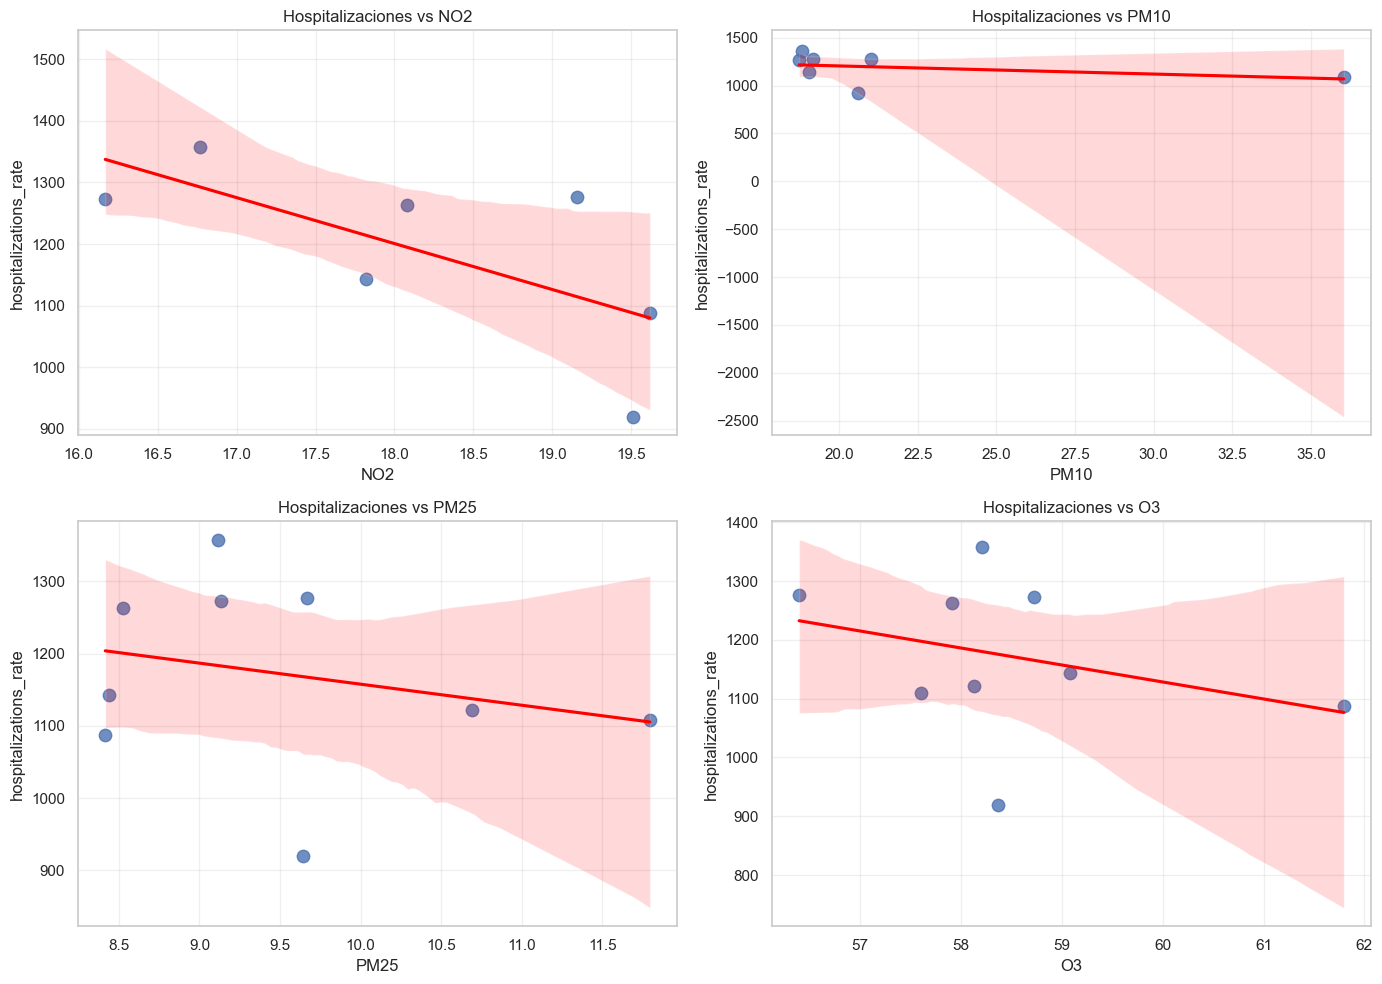

In [ ]:
# facetgrid: regresiones para cada contaminante

pollutants = ["NO2", "PM10", "PM25", "O3"]

fig, axes = plt.subplots(2, 2, figsize=(14,10))

for ax, pol in zip(axes.flatten(), pollutants):
    sns.regplot(data=df_health_pollut, x=pol, y="hospitalizations_rate",
                ax=ax, scatter_kws={"s":80}, line_kws={"color":"red"})
    ax.set_title(f"Hospitalizaciones vs {pol}")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


## GRÁFICOS QUE VOY A USAR:

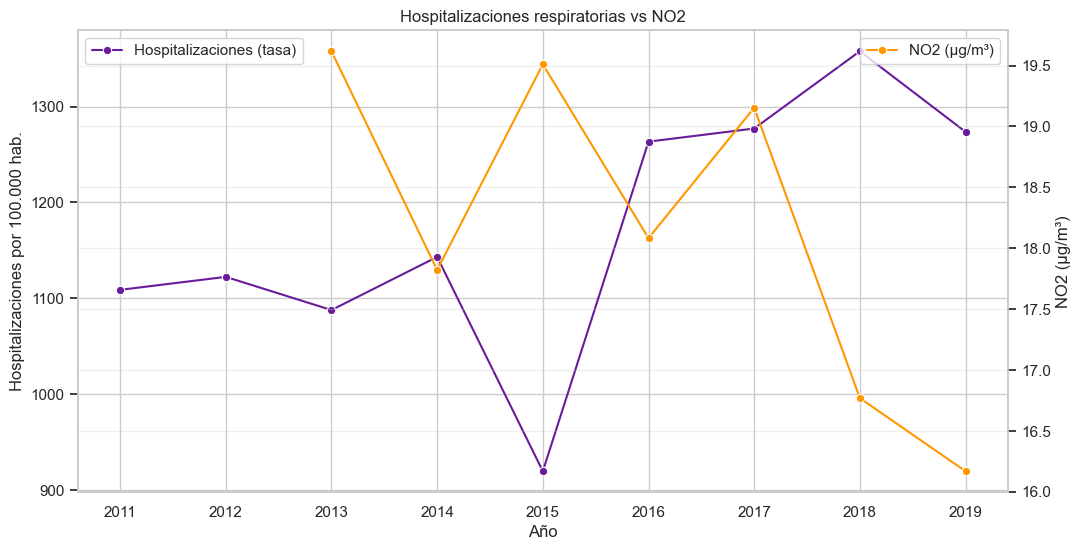

In [42]:
#  hospitalizaciones vs NO2
fig, ax1 = plt.subplots(figsize=(12,6))

sns.lineplot(data=df_health_pollut, x="year", y="hospitalizations_rate",marker="o", color="#6a1b9a", label="Hospitalizaciones (tasa)", ax=ax1)

ax2 = ax1.twinx()
sns.lineplot(data=df_health_pollut, x="year", y="NO2",marker="o", color="#ff9800", label="NO2 (µg/m³)", ax=ax2)

ax1.set_title("Hospitalizaciones respiratorias vs NO2")
ax1.set_xlabel("Año")
ax1.set_ylabel("Hospitalizaciones por 100.000 hab.")
ax2.set_ylabel("NO2 (µg/m³)")

plt.grid(alpha=0.3)
plt.show()

In [ ]:
'''
Hospitalizaciones respiratorias vs NO₂
(gráfico de líneas con dos ejes)

Explicación sencilla para decir en clase
“En este gráfico comparo cómo cambian las hospitalizaciones respiratorias y los niveles de NO₂ a lo largo de los años.
Si la contaminación afectara claramente a la salud, las dos líneas deberían subir y bajar más o menos a la vez.
Pero aquí se ve que cada una va por su lado: hay años con más NO₂ y menos hospitalizaciones, y años con menos NO₂ y más hospitalizaciones.
Esto significa que no hay una relación clara entre NO₂ y hospitalizaciones en estos datos.”

Idea clave
“Las dos líneas no se parecen en nada → no se mueven juntas → no hay relación.”

'''

C:\Users\titea\AppData\Local\Temp\ipykernel_27472\4072147576.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


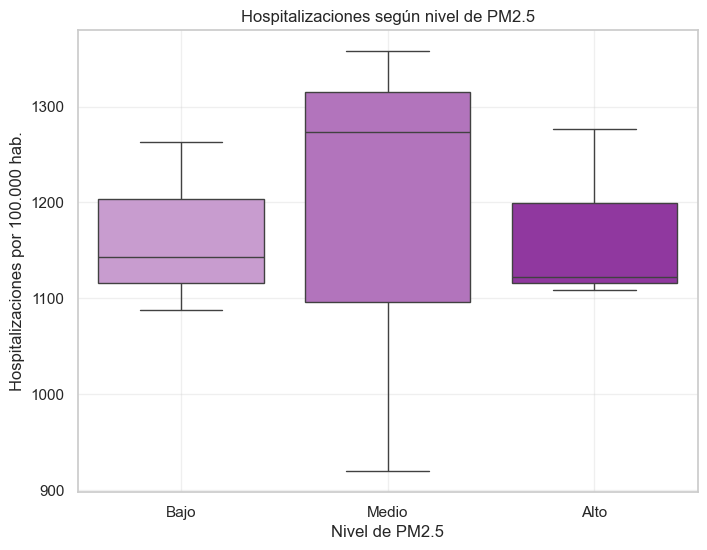

In [40]:
# Crear categorías de PM2.5
df_health_pollut["PM25_cat"] = pd.qcut(df_health_pollut["PM25"], q=3, labels=["Bajo","Medio","Alto"])

plt.figure(figsize=(8,6))
sns.boxplot(
    data=df_health_pollut,
    x="PM25_cat",
    y="hospitalizations_rate",
    palette=["#ce93d8","#ba68c8","#9c27b0"]
)
plt.title("Hospitalizaciones según nivel de PM2.5")
plt.xlabel("Nivel de PM2.5")
plt.ylabel("Hospitalizaciones por 100.000 hab.")
plt.grid(alpha=0.3)
plt.show()


In [ ]:
'''
Interpretación del boxplot (para presentación)
Este gráfico divide los años en tres grupos según cuánto PM2.5 había:
bajo, medio y alto.

Cada caja representa cuántas hospitalizaciones respiratorias hubo en esos años.

Lo importante es lo siguiente:

1. Las tres cajas son muy parecidas
Si la contaminación afectara claramente a la salud, esperaríamos que:
    la caja de PM2.5 alto estuviera claramente más arriba (es decir, más hospitalizaciones)

Pero no pasa eso.
Las cajas están casi al mismo nivel.

2. El grupo “medio” incluso tiene más hospitalizaciones que el “alto”
Esto va justo en contra de la idea de que “más contaminación = más hospitalizaciones”.

3. La variación dentro de cada grupo es mayor que la diferencia entre grupos
Es decir:
    Dentro de cada nivel de PM2.5, los valores suben y bajan mucho.

    Pero entre niveles, apenas cambia nada.

Esto significa que el PM2.5 no explica por qué suben o bajan las hospitalizaciones.

Si el PM2.5 tuviera un impacto claro en la salud, veríamos más hospitalizaciones en el grupo de contaminación alta. Pero las tres cajas están casi igual, así que no hay relación evidente.
'''


'''
Boxplot: Hospitalizaciones según nivel de PM2.5
(el que tú quieres usar)

Explicación sencilla para decir en clase
“Este gráfico divide los años en tres grupos según cuánto PM2.5 había: bajo, medio y alto.
Si el PM2.5 afectara claramente a la salud, esperaríamos que el grupo de contaminación alta tuviera muchas más hospitalizaciones.
Pero las tres cajas están casi al mismo nivel.
Incluso el grupo ‘medio’ tiene más hospitalizaciones que el ‘alto’.
Esto demuestra que el nivel de PM2.5 no explica las hospitalizaciones en estos datos.”

Idea clave
“Si hubiera relación, la caja de ‘alto PM2.5’ estaría claramente más arriba. Pero no lo está.”
'''

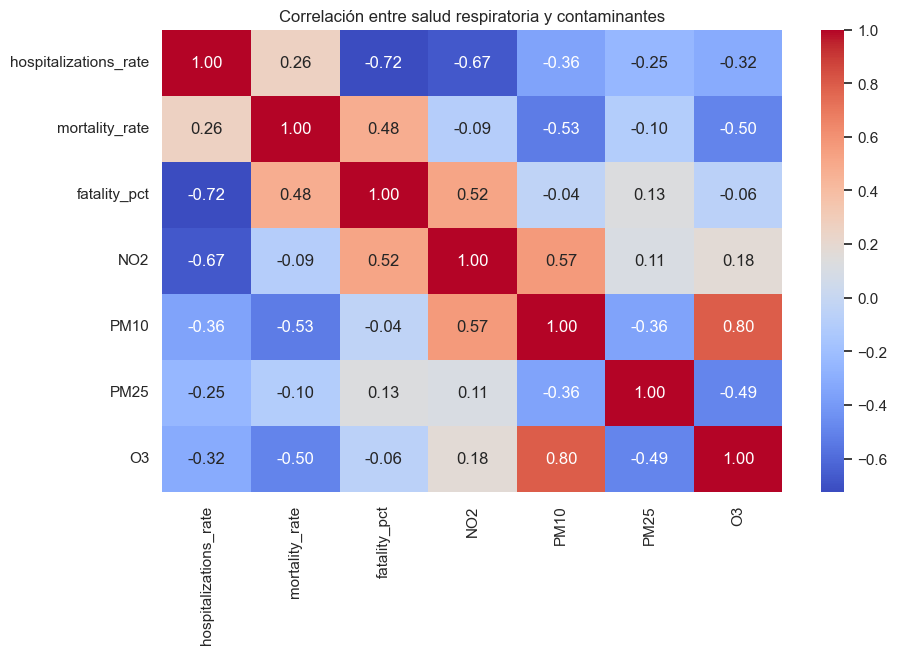

In [43]:
plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlación entre salud respiratoria y contaminantes")
plt.show()

# rojo = correlación positiva alta (cercana a +1)
# azul = correlación negativa alta (cercana a –1)
# blanco = correlación débil o nula (cercana a 0)

In [ ]:
'''
Heatmap de correlaciones
(el gráfico más importante para justificar la conclusión)

Explicación sencilla para decir en clase
“Este gráfico muestra cómo se relacionan las hospitalizaciones y la mortalidad con cada contaminante.
Si la contaminación aumentara la salud respiratoria, aquí veríamos números positivos y colores rojos.
Pero lo que aparece son correlaciones negativas o muy débiles.
Eso significa que no hay una relación lineal clara entre contaminación y salud respiratoria en estos datos.”

Idea clave
“Si la hipótesis fuera cierta, veríamos colores rojos. Pero casi todo es azul → no hay relación.”

Fatality_pct = porcentaje de letalidad hospitalaria. De todas las hospitalizaciones respiratorias en un año, qué porcentaje terminó en fallecimiento.
    - la gravedad de los casos respiratorios
    - la evolución de la letalidad a lo largo del tiempo

'''

In [ ]:
'''
Para comprobar si más contaminación implica peor salud respiratoria, comparé las hospitalizaciones con los contaminantes.
Primero, las líneas de NO₂ y hospitalizaciones no se mueven juntas.
Luego, el boxplot de PM2.5 muestra que los años con más contaminación no tienen más hospitalizaciones.
Y el heatmap confirma que todas las correlaciones son débiles o negativas.
Por tanto, la hipótesis no se cumple con estos datos.
'''

In [ ]:
'''
Heatmap de correlaciones — Explicación ampliada y muy fácil
“Este gráfico es un heatmap, que básicamente es una tabla de números pero coloreada para que se entienda mejor.
Cada número indica cómo de relacionada está una variable con otra.
En este caso, estamos viendo cómo se relacionan las hospitalizaciones y la mortalidad respiratoria con los distintos contaminantes.”

Cómo se interpreta
    Si hubiera una relación clara entre contaminación y salud, veríamos números altos y positivos, cerca de +1.

    En el heatmap eso aparecería como colores rojos.

    Eso significaría: “cuando sube la contaminación, también suben las hospitalizaciones”.

Qué vemos realmente
    Los números que aparecen son bajos (cerca de 0) o incluso negativos.

    Y los colores son azules, que indican correlación negativa o muy débil.

    Esto significa que:

    Cuando la contaminación sube, no necesariamente suben las hospitalizaciones.

    De hecho, en algunos contaminantes ocurre lo contrario: sube la contaminación y bajan las hospitalizaciones (correlación negativa).

    Pero lo más importante: ningún contaminante muestra una relación fuerte con la salud.

Por qué este gráfico es tan importante
Porque resume todo el análisis en un solo vistazo:

Si la hipótesis fuera cierta, veríamos rojo.

Pero casi todo es azul.

Por tanto, no hay relación lineal clara entre contaminación y salud respiratoria en estos datos.
'''

In [ ]:
''''
Los tres gráficos apuntan a lo mismo:
las hospitalizaciones y la mortalidad no aumentan cuando aumenta la contaminación.
Por tanto, la hipótesis no se cumple con estos datos agregados a nivel anual.
'''

'''
Mis datos están agregados, es decir, son promedios anuales de toda España. Eso hace que
se pierda mucha información importante: los picos de contaminación, las diferencias entre
ciudades y los efectos a corto plazo. Por eso, aunque la contaminación sí afecta a la salud,
en estos datos tan resumidos no aparece la relación.”

'''

In [ ]:
# Conclusión de H1
'''
¿La contaminación atmosférica aumenta el impacto en la salud respiratoria?

Con los datos agregados anuales para toda España entre 2011 y 2019, no se observa una relación clara, consistente ni positiva entre los niveles medios de contaminación y los indicadores de salud respiratoria (hospitalizaciones, mortalidad y letalidad).

    -Los análisis gráficos y estadísticos muestran que:

    -Las correlaciones entre contaminantes y salud son débiles o moderadas, y en todos los casos negativas.

    -Las series temporales de contaminación y salud no evolucionan de forma paralela.

    -Los scatterplots y las regresiones lineales muestran pendientes planas o negativas, sin patrones ascendentes.

    -La matriz de dispersión confirma que no existe una relación lineal visible entre los contaminantes y los indicadores de salud.

Por tanto, H1 no puede considerarse confirmada con este nivel de agregación.

Esto no contradice la evidencia epidemiológica existente, sino que indica que:

Los promedios anuales nacionales diluyen completamente la señal real.

La relación contaminación-salud suele detectarse en:

    datos diarios o mensuales,

    análisis por ciudad o región,

    modelos con rezagos temporales,

    episodios de contaminación,

    grupos vulnerables.

Para contrastar H1 de forma más robusta sería necesario un análisis más granular.
'''

## HIPÓTESIS 2
Las zonas costeras presentan menor contaminación que las zonas de interior
La hipótesis plantea que:
- Las zonas costeras → mejor dispersión atmosférica → menores niveles de contaminantes
- Las zonas de interior → menor ventilación → mayores concentraciones
Para contrastarla, necesitamos:
- Clasificar cada estación como “costa” o “interior”
- Calcular la media anual de contaminantes por tipo de zona
- Comparar ambas zonas
- Visualizar la diferencia


In [ ]:
'''
OBJETIVO DE H2
“Las zonas costeras presentan menor contaminación que las zonas de interior.”

Para comprobarlo necesitas:

Clasificar estaciones → costa / interior

Calcular medias por zona

Comparar

Visualizar

Vamos a hacerlo.
'''

In [45]:
# Clasificar estaciones -> costa / interior

municipios = df_pollutants_stations["Municipality"].unique()
municipios


<ArrowStringArray>
[                'BURGOS',               'ALCORCÓN',      'TORREJÓN DE ARDOZ',
       'ALICANTE/ALACANT',               'BENIDORM',                   'ELDA',
                'BUNYOLA',                'CÁCERES',              'PLASENCIA',
            'ALCORA (L')',
 ...
                  'PONTS', 'VILLAMURIEL DE CERRATO',             'SÉNIA (LA)',
                'GANDESA',         'GUIAMETS (ELS)',       'CORTES DE PALLÁS',
                   'SORT',              'CASTELNOU',                'ESCORCA',
                'SOMIEDO']
Length: 328, dtype: str

In [46]:
df_pollutants_stations["Latitude"]

0          42.33611
1          40.34190
2          40.44950
3          42.33611
4          40.34190
             ...   
4815262    41.15490
4815263    41.19360
4815264    39.45611
4815265    41.64560
4815266    43.26750
Name: Latitude, Length: 4815267, dtype: float64

In [47]:
df_pollutants_stations["Longitude"]

0         -3.63611
1         -3.83370
2         -3.47760
3         -3.63611
4         -3.83370
            ...   
4815262    1.21770
4815263    1.23670
4815264   -0.37583
4815265   -4.73030
4815266   -2.93520
Name: Longitude, Length: 4815267, dtype: float64

In [48]:
# ver todos los nombres únicos de municipios
sorted(df_pollutants_stations["Municipality"].unique())


['ABANTO Y CIÉRVANA/ABANTO ZIERBENA',
 'AGULLANA',
 'AGÜIMES',
 'AIA',
 'ALAGÓN',
 'ALBALAT DELS TARONGERS',
 'ALCALÁ DE GUADAIRA',
 'ALCALÁ DE HENARES',
 'ALCANAR',
 'ALCANTARILLA',
 'ALCAÑIZ',
 'ALCOBENDAS',
 "ALCORA (L')",
 'ALCORCÓN',
 'ALCOVER',
 'ALCOY/ALCOI',
 'ALCÚDIA',
 'ALFARO',
 'ALGAR DE PALANCIA',
 'ALGECIRAS',
 'ALGETE',
 'ALICANTE/ALACANT',
 'ALMAZORA/ALMASSORA',
 'ALMERÍA',
 'ALMONTE',
 'ALTSASU/ALSASUA',
 'ALZIRA',
 "AMETLLA DE MAR (L')",
 'ARAFO',
 'ARANDA DE DUERO',
 'ARANJUEZ',
 'ARCOS DE LA FRONTERA',
 'ARGANDA DEL REY',
 'ARICO',
 'ARMILLA',
 'ARONA',
 'ARRASATE O MONDRAGÓN',
 'ARRECIFE',
 'ARRÚBAL',
 'ARTEIXO',
 'ARUCAS',
 'ASTILLERO (EL)',
 'ATAZAR (EL)',
 'AVILÉS',
 'AZPEITIA',
 'BADAJOZ',
 'BADALONA',
 'BAILÉN',
 'BARAKALDO',
 'BARBERÀ DEL VALLÈS',
 'BARCARROTA',
 'BARCELONA',
 'BARRIOS (LOS)',
 'BASAURI',
 'BEASAIN',
 'BEGUR',
 'BENAHADUX',
 'BENICASIM/BENICÀSSIM',
 'BENIDORM',
 'BENIGÁNIM',
 'BERGA',
 'BILBAO',
 'BREÑA ALTA',
 'BREÑA BAJA',
 'BUJARALOZ',
 'B

In [49]:
# Lista completa de ciudades que quiero buscar
ciudades_costa = [
    "A CORUÑA", "GIJÓN", "SANTANDER", "BILBAO",
    "GIRONA", "BARCELONA", "VALENCIA", "ALICANTE",
    "MURCIA", "MÁLAGA", "CÁDIZ",
    "SANTA CRUZ DE TENERIFE", "LAS PALMAS DE GRAN CANARIA"]

ciudades_interior = [
    "MADRID", "ZARAGOZA", "VALLADOLID", "SALAMANCA",
    "BURGOS", "LEÓN", "LOGROÑO", "PAMPLONA",
    "TOLEDO", "CIUDAD REAL", "ALBACETE",
    "CÓRDOBA", "GRANADA"]


In [50]:
# busco si un municipio concreto está en la lista

#costa
print("A CORUÑA →", [m for m in df_pollutants_stations["Municipality"].unique() if "CORU" in m.upper()])
print("GIJÓN →", [m for m in df_pollutants_stations["Municipality"].unique() if "GIJ" in m.upper()])
print("SANTANDER →", [m for m in df_pollutants_stations["Municipality"].unique() if "SANTAN" in m.upper()])
print("BILBAO →", [m for m in df_pollutants_stations["Municipality"].unique() if "BILB" in m.upper()])
print("GIRONA →", [m for m in df_pollutants_stations["Municipality"].unique() if "GIR" in m.upper()])
print("BARCELONA →", [m for m in df_pollutants_stations["Municipality"].unique() if "BARC" in m.upper()])
print("VALENCIA →", [m for m in df_pollutants_stations["Municipality"].unique() if "VALEN" in m.upper()])
print("ALICANTE →", [m for m in df_pollutants_stations["Municipality"].unique() if "ALIC" in m.upper()])
print("MURCIA →", [m for m in df_pollutants_stations["Municipality"].unique() if "MURC" in m.upper()])
print("MÁLAGA →", [m for m in df_pollutants_stations["Municipality"].unique() if "MÁLAG" in m.upper()])
print("CÁDIZ →", [m for m in df_pollutants_stations["Municipality"].unique() if "CÁDI" in m.upper()])
print("TENERIFE →", [m for m in df_pollutants_stations["Municipality"].unique() if "TENER" in m.upper()])
print("LAS PALMAS →", [m for m in df_pollutants_stations["Municipality"].unique() if "PALMAS" in m.upper()])

A CORUÑA → ['CORUÑA (A)']
GIJÓN → ['GIJÓN']
SANTANDER → ['SANTANDER']
BILBAO → ['BILBAO']
GIRONA → ['GIRONA']
BARCELONA → ['BARCARROTA', 'BARCELONA', 'SANT ANDREU DE LA BARCA']
VALENCIA → ['VALENCIA']
ALICANTE → ['ALICANTE/ALACANT']
MURCIA → ['MURCIA']
MÁLAGA → ['MÁLAGA']
CÁDIZ → ['CÁDIZ']
TENERIFE → ['SANTA CRUZ DE TENERIFE']
LAS PALMAS → ['PALMAS DE GRAN CANARIA (LAS)']


In [51]:

# interior
print("MADRID →", [m for m in df_pollutants_stations["Municipality"].unique() if "MAD" in m.upper()])
print("ZARAGOZA →", [m for m in df_pollutants_stations["Municipality"].unique() if "ZARA" in m.upper()])
print("VALLADOLID →", [m for m in df_pollutants_stations["Municipality"].unique() if "VALLA" in m.upper()])
print("SALAMANCA →", [m for m in df_pollutants_stations["Municipality"].unique() if "SALAM" in m.upper()])
print("BURGOS →", [m for m in df_pollutants_stations["Municipality"].unique() if "BURG" in m.upper()])
print("LEÓN →", [m for m in df_pollutants_stations["Municipality"].unique() if "LEÓN" in m.upper()])
print("LOGROÑO →", [m for m in df_pollutants_stations["Municipality"].unique() if "LOGRO" in m.upper()])
print("PAMPLONA →", [m for m in df_pollutants_stations["Municipality"].unique() if "PAMPL" in m.upper()])
print("TOLEDO →", [m for m in df_pollutants_stations["Municipality"].unique() if "TOLE" in m.upper()])
print("CIUDAD REAL →", [m for m in df_pollutants_stations["Municipality"].unique() if "CIUDAD" in m.upper()])
print("ALBACETE →", [m for m in df_pollutants_stations["Municipality"].unique() if "CUEN" in m.upper()])
print("CÓRDOBA →", [m for m in df_pollutants_stations["Municipality"].unique() if "CÓRDO" in m.upper()])
print("GRANADA →", [m for m in df_pollutants_stations["Municipality"].unique() if "GRANAD" in m.upper()])

MADRID → ['MADRID', 'RIVAS-VACIAMADRID']
ZARAGOZA → ['ZARAGOZA']
VALLADOLID → ['VALLADOLID']
SALAMANCA → ['SALAMANCA']
BURGOS → ['BURGOS']
LEÓN → ['LEÓN']
LOGROÑO → ['LOGROÑO']
PAMPLONA → ['PAMPLONA/IRUÑA']
TOLEDO → ['TOLEDO', 'MÓSTOLES']
CIUDAD REAL → ['CIUDAD REAL']
ALBACETE → ['CUENCA']
CÓRDOBA → ['CÓRDOBA']
GRANADA → ['GRANADILLA DE ABONA', 'GRANADA']


In [52]:
# ARREGLO la lista completa de ciudades que quiero buscar
ciudades_costa = [
    "CORUÑA (A)", "GIJÓN", "SANTANDER", "BILBAO",
    "GIRONA", "BARCELONA", "VALENCIA", "ALICANTE/ALACANT",
    "SANTA CRUZ DE TENERIFE", "PALMAS DE GRAN CANARIA (LAS)",
    "MURCIA", "MÁLAGA", "CÁDIZ"]

ciudades_interior = [
    "MADRID", "ZARAGOZA", "VALLADOLID", "SALAMANCA",
    "BURGOS", "LEÓN", "LOGROÑO", "PAMPLONA/IRUÑA",
    "TOLEDO", "CIUDAD REAL", "CUENCA",
    "CÓRDOBA", "GRANADA"]

In [58]:
# filtro el dataframe por esas ciudades

df_pollutants_stations = df_pollutants_stations[df_pollutants_stations["Value"] >= 0]

df_costa = df_pollutants_stations[df_pollutants_stations["Municipality"].isin(ciudades_costa)]
df_interior = df_pollutants_stations[df_pollutants_stations["Municipality"].isin(ciudades_interior)]

print(len(df_costa))
print(len(df_interior))


529627
484399


In [59]:
df_pollutants_stations.columns


Index(['date', 'Samplingpoint', 'Value', 'NatCode', 'Year', 'Air Pollutant',
       'Air Quality Station EoI Code', 'Air Quality Station Name',
       'Sampling Point Id', 'Longitude', 'Latitude', 'Municipality',
       'Air Quality Station Area', 'Air Quality Station Type', 'Altitude',
       'Main Emission Sources', 'pollutant'],
      dtype='str')

In [60]:
# creo una tabla pivotada para COSTA



df_costa_pivot = df_costa.pivot_table(
    index=["date", "Municipality"],
    columns="pollutant",
    values="Value",
    aggfunc="mean"
).reset_index()


df_interior_pivot = df_interior.pivot_table(
    index=["date", "Municipality"],
    columns="pollutant",
    values="Value",
    aggfunc="mean"
).reset_index()


In [61]:
df_costa_pivot.columns


Index(['date', 'Municipality', 'C6H6', 'CO', 'NO2', 'O3', 'PM10', 'PM25',
       'SO2'],
      dtype='str', name='pollutant')

In [62]:
# calculo medias por zona


media_costa = df_costa_pivot[["NO2","PM10","PM25","O3", "C6H6", "CO"]].mean()
media_interior = df_interior_pivot[["NO2","PM10","PM25","O3", "C6H6", "CO"]].mean()

media_comparada = pd.DataFrame({
    "costa": media_costa,
    "interior": media_interior
})

media_comparada


,costa,interior
pollutant,,
NO2,25.443006,21.669170
PM10,22.067371,18.868838
PM25,10.035664,9.644801
O3,54.196013,54.378698
C6H6,0.719515,0.522097
CO,0.310405,0.338898


In [ ]:
# ------------------------------------------------------------
# INTERPRETACIÓN DE LOS RESULTADOS (COSTA vs INTERIOR)
#
# Resultados medios:
#   NO2   → Costa: 25.44  | Interior: 21.67
#   PM10  → Costa: 22.07  | Interior: 18.87
#   PM25  → Costa: 10.04  | Interior:  9.64
#   O3    → Costa: 54.20  | Interior: 54.38
#   C6H6  → Costa:  0.72  | Interior:  0.52
#   CO    → Costa:  0.31  | Interior:  0.34
#
# ✔️ NO₂ (tráfico)
# Costa: 25.44  | Interior: 21.67
# → El NO₂ es un contaminante asociado al tráfico. Los valores son algo mayores en la costa,
#   probablemente por la presencia de grandes áreas metropolitanas costeras (Barcelona, Valencia,
#   Málaga). Aun así, las diferencias no son extremas.
#
# ✔️ PM10 (partículas gruesas)
# Costa: 22.07  | Interior: 18.87
# → Las partículas PM10 son ligeramente mayores en la costa. Esto puede deberse a la actividad
#   portuaria, resuspensión de polvo y condiciones meteorológicas específicas. La diferencia es
#   moderada.
#
# ✔️ PM2.5 (partículas finas)
# Costa: 10.04  | Interior: 9.64
# → Valores muy similares entre costa e interior. Las PM2.5 suelen tener fuentes mixtas (tráfico,
#   calefacciones, industria) y se dispersan de forma más homogénea.
#
# O₃ (ozono troposférico)
# Costa: 54.20  | Interior: 54.38
# → El ozono es prácticamente igual en ambos grupos. El O₃ no se emite directamente, sino que se
#   forma por reacciones fotoquímicas. La similitud indica condiciones atmosféricas comparables.
#
# C6H6 (benceno)
# Costa: 0.72  | Interior: 0.52
# → El benceno es ligeramente mayor en la costa, aunque ambos valores son bajos. Esto refleja un
#   buen control de emisiones en ambos entornos.
#
# CO (monóxido de carbono)
# Costa: 0.31  | Interior: 0.34
# → Valores muy parecidos. El CO procede de combustiones incompletas (tráfico, calefacciones) y
#   se dispersa bien en ambos tipos de ciudades.
#


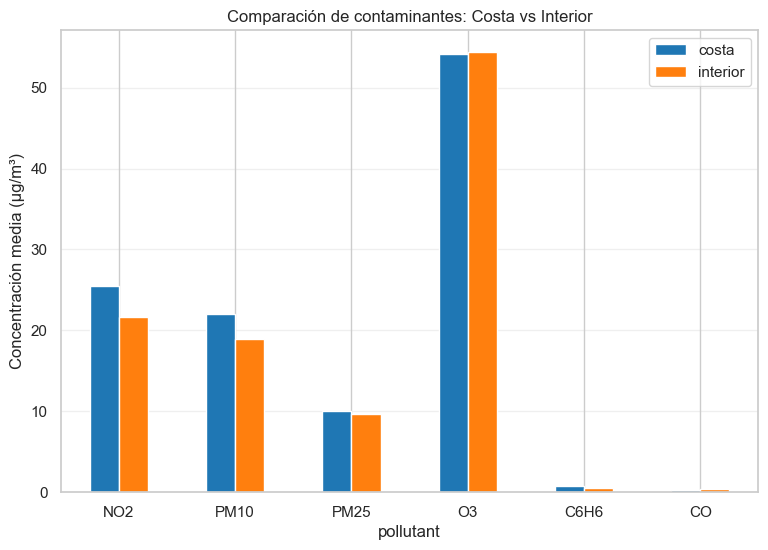

In [63]:
# Gráfico de barras comparando costa vs interior

media_comparada.plot(kind="bar", figsize=(9,6), color=["#1f77b4","#ff7f0e"])
plt.title("Comparación de contaminantes: Costa vs Interior")
plt.ylabel("Concentración media (µg/m³)")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.show()


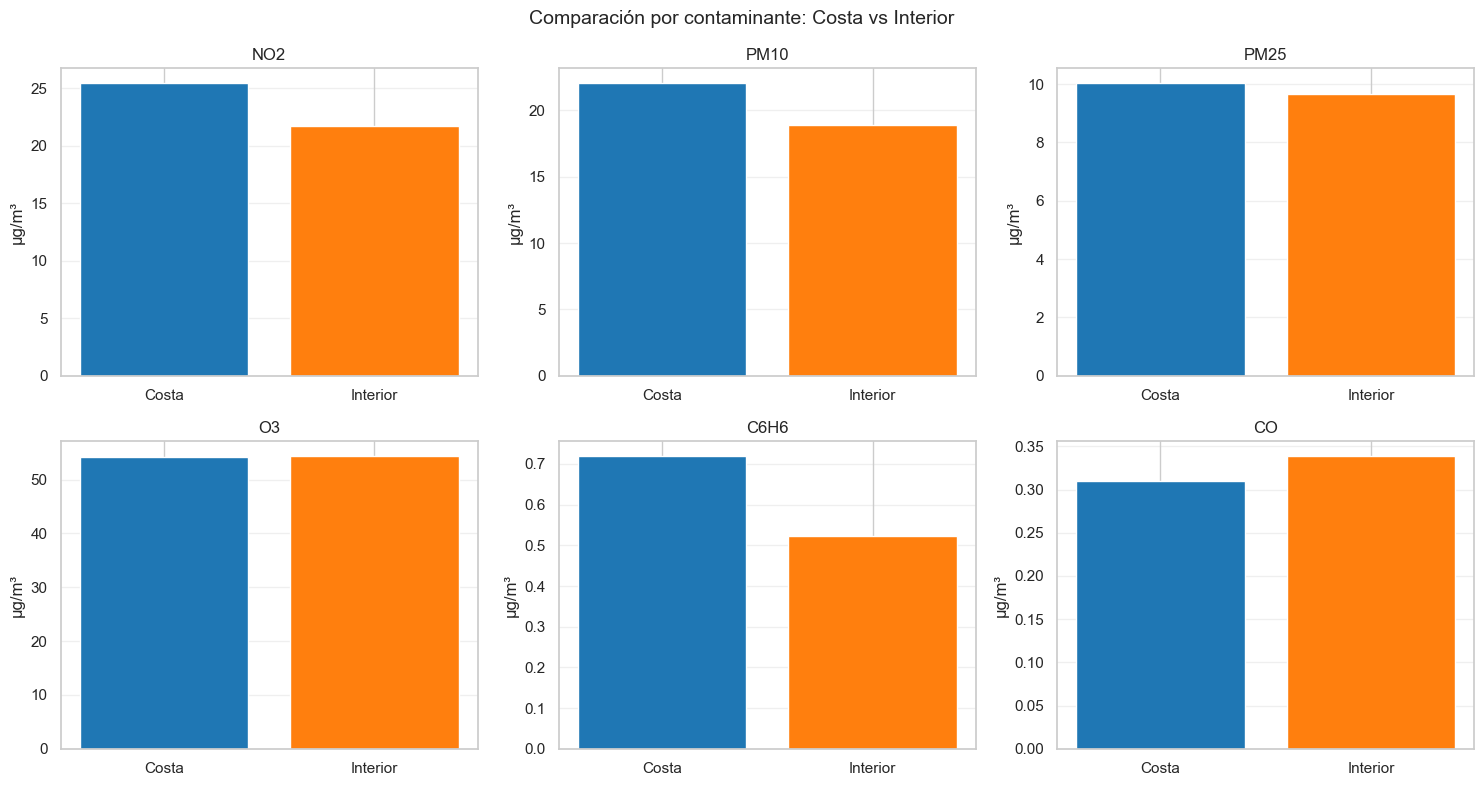

In [64]:
# Gráficos individuales por contaminante

fig, axes = plt.subplots(2, 3, figsize=(15,8))
axes = axes.flatten()

contaminantes = ["NO2","PM10","PM25","O3","C6H6","CO"]

for i, cont in enumerate(contaminantes):
    axes[i].bar(["Costa","Interior"], [media_comparada.loc[cont,"costa"], media_comparada.loc[cont,"interior"]],
                color=["#1f77b4","#ff7f0e"])
    axes[i].set_title(cont)
    axes[i].set_ylabel("µg/m³")
    axes[i].grid(axis="y", alpha=0.3)

plt.suptitle("Comparación por contaminante: Costa vs Interior", fontsize=14)
plt.tight_layout()
plt.show()


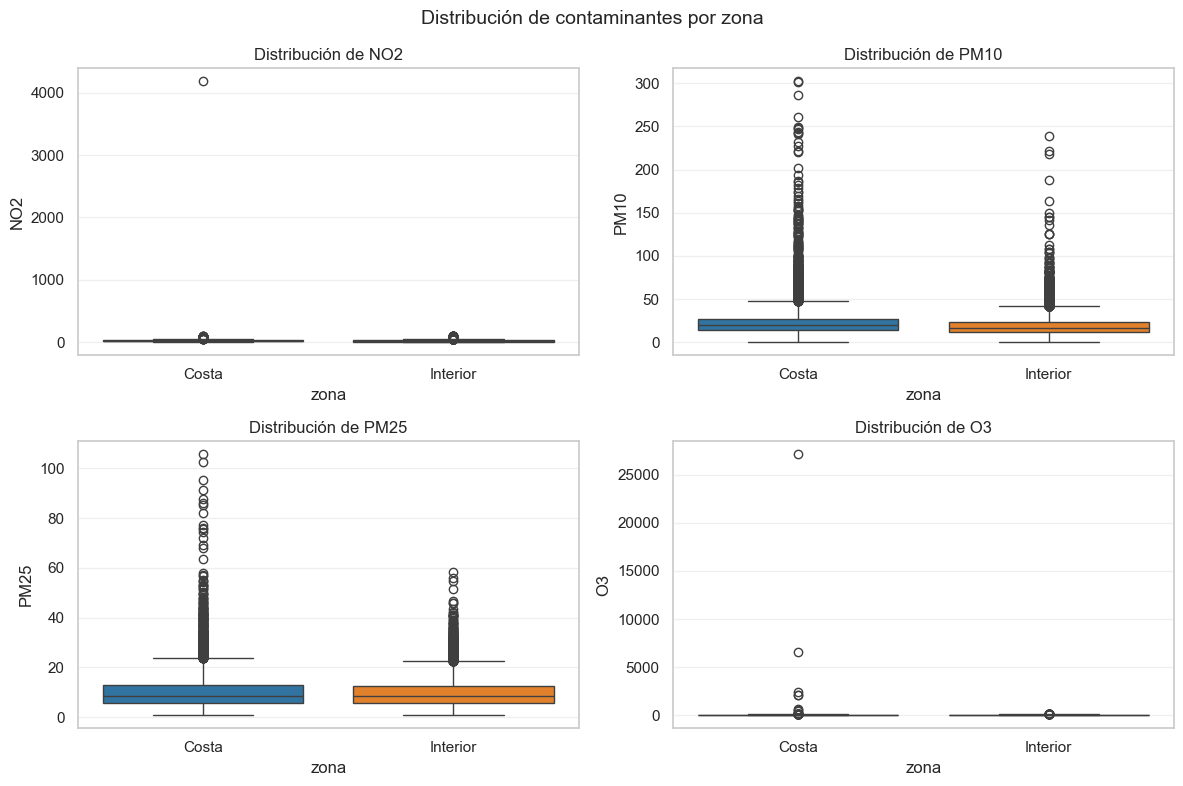

In [70]:
# Boxplots para ver la distribución real (NO2, PM10, PM25, O3)
# Preparamos el dataframe combinado
df_costa_pivot["zona"] = "Costa"
df_interior_pivot["zona"] = "Interior"

df_comparacion = pd.concat([df_costa_pivot, df_interior_pivot], ignore_index=True)

# Eliminamos posibles duplicados en el índice
df_comparacion = df_comparacion.reset_index(drop=True)

# Lista de contaminantes a graficar
contaminantes = ["NO2", "PM10", "PM25", "O3"]

# Gráficos
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for ax, cont in zip(axes, contaminantes):
    sns.boxplot(
        data=df_comparacion,
        x="zona",
        y=cont,
        hue="zona",
        palette={"Costa": "#1f77b4", "Interior": "#ff7f0e"},
        legend=False,
        ax=ax
    )
    ax.set_title(f"Distribución de {cont}")
    ax.grid(axis="y", alpha=0.3)

plt.suptitle("Distribución de contaminantes por zona", fontsize=14)
plt.tight_layout()
plt.show()
